# EDA - Freight Rate Prediction

Exploring `data/train-test.csv` (48,000 labeled loads, Jan–Oct 2025) to inform cleaning,
feature engineering, and model choice.

Uses the project's time-based splits (`data.make_splits`) so we look primarily at the
**train** portion (Jan–Aug) to avoid peeking at dev/holdout during EDA.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data import load_data, make_splits

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100

raw = load_data()
splits = make_splits(raw)
train = splits.train.copy()
train["date"] = pd.to_datetime(train["date"])
print(f"raw: {raw.shape} | train (Jan-Aug, for EDA): {train.shape}")
train.head()

raw: (48000, 14) | train (Jan-Aug, for EDA): (38477, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 1. Schema, dtypes, and missingness

In [2]:
train.info()
print()
na_counts = train.isna().sum()
print("Missing values (train):")
print(na_counts[na_counts > 0])

<class 'pandas.core.frame.DataFrame'>
Index: 38477 entries, 0 to 38476
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   load_id       38477 non-null  object        
 1   pickup        38477 non-null  object        
 2   delivery      38477 non-null  object        
 3   pickup_lat    38477 non-null  float64       
 4   pickup_lon    38477 non-null  float64       
 5   delivery_lat  38477 non-null  float64       
 6   delivery_lon  38477 non-null  float64       
 7   distance      38477 non-null  float64       
 8   equipment     38477 non-null  object        
 9   weight        38242 non-null  float64       
 10  date          38477 non-null  datetime64[ns]
 11  market_index  38176 non-null  float64       
 12  quote_signal  38477 non-null  float64       
 13  posted_rate   38477 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(4)
memory usage: 4.4+ MB

Missing values (train):


## 2. Target: `posted_rate`

Right-skewed with a long tail, which informs the log-transform decision for modeling.

count    38477.00
mean      2369.41
std       1476.50
min         57.22
25%       1254.45
50%       2026.04
75%       3329.34
max      25533.00
Name: posted_rate, dtype: float64
skew: 1.898
skew of log1p(rate): -0.494


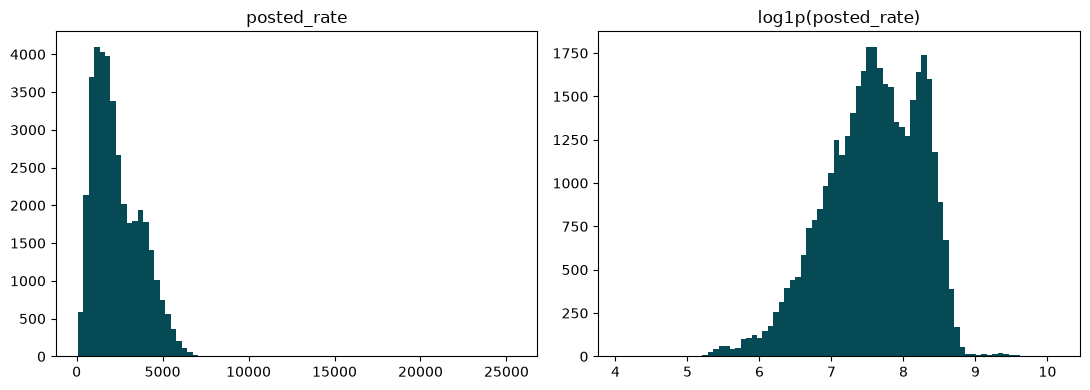

In [3]:
print(train["posted_rate"].describe().round(2))
print("skew:", round(train["posted_rate"].skew(), 3))
print("skew of log1p(rate):", round(np.log1p(train["posted_rate"]).skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train["posted_rate"], bins=80, color="#064A56")
axes[0].set_title("posted_rate")
axes[1].hist(np.log1p(train["posted_rate"]), bins=80, color="#064A56")
axes[1].set_title("log1p(posted_rate)")
fig.tight_layout()
plt.show()

### High-rate outliers

Check the top of the distribution: is it plausible (long-haul, heavy loads), or a data-quality issue?

In [4]:
cols = ["load_id", "pickup", "delivery", "distance", "equipment", "weight", "posted_rate"]
print("Top 10 by posted_rate:")
display(train.nlargest(10, "posted_rate")[cols])
print("\nBottom 10 by posted_rate:")
display(train.nsmallest(10, "posted_rate")[cols])

q99_5 = train["posted_rate"].quantile(0.995)
print(f"\n99.5th percentile: {q99_5:.0f} | rows above it: {(train['posted_rate'] > q99_5).sum()}")

Top 10 by posted_rate:


,load_id,pickup,delivery,distance,equipment,weight,posted_rate
12184,TR-012185,Bakersfield,Hartford,2829.8,Dry Van,33153.0,25533.00
37764,TR-037765,Phoenix,Syracuse,2810.9,Dry Van,33674.0,24294.98
1466,TR-001467,Los Angeles,Syracuse,2786.0,Reefer,30322.0,24140.21
17371,TR-017372,Reno,Philadelphia,2777.6,Reefer,33158.0,23662.71
26235,TR-026236,Charleston,Phoenix,2552.5,Dry Van,25665.0,23580.42
28219,TR-028220,Tucson,Raleigh,2423.3,Dry Van,30972.0,22755.66
3353,TR-003354,Phoenix,Charleston,2527.9,Reefer,36840.0,22534.65
31259,TR-031260,Oklahoma City,Baltimore,1747.7,Reefer,28876.0,19042.39
34583,TR-034584,Atlanta,Fresno,2242.0,Dry Van,32005.0,18972.15
20245,TR-020246,Atlanta,Los Angeles,2153.5,Reefer,31758.0,17772.53



Bottom 10 by posted_rate:


,load_id,pickup,delivery,distance,equipment,weight,posted_rate
5961,TR-005962,Grand Rapids,Green Bay,105.5,Dry Van,24598.0,57.22
30705,TR-030706,Hartford,New York,114.4,Dry Van,25901.0,59.68
14990,TR-014991,Los Angeles,Phoenix,93.9,Reefer,32284.0,63.36
872,TR-000873,Cincinnati,Lexington,144.0,Dry Van,13535.0,67.80
4674,TR-004675,Hartford,Baltimore,149.3,Reefer,27506.0,75.19
9137,TR-009138,Fort Wayne,Toledo,105.0,Reefer,35124.0,76.54
34343,TR-034344,Louisville,Cincinnati,70.0,Dry Van,35673.0,82.38
10959,TR-010960,Lubbock,San Antonio,122.6,Reefer,42648.0,94.72
18954,TR-018955,Cincinnati,St. Louis,228.7,Dry Van,25262.0,101.63
11236,TR-011237,Columbia,Lexington,228.3,Dry Van,22221.0,103.15



99.5th percentile: 6469 | rows above it: 193


## 3. Distance: the dominant predictor

`distance` correlates strongly with `posted_rate`. Check linearity, per-mile rate behavior
(does rate/mile fall with distance, reflecting economies of scale, or does it stay flat?), and
whether the relationship differs by equipment type.

corr(distance, posted_rate): 0.9099
corr(distance, log1p(posted_rate)): 0.8991


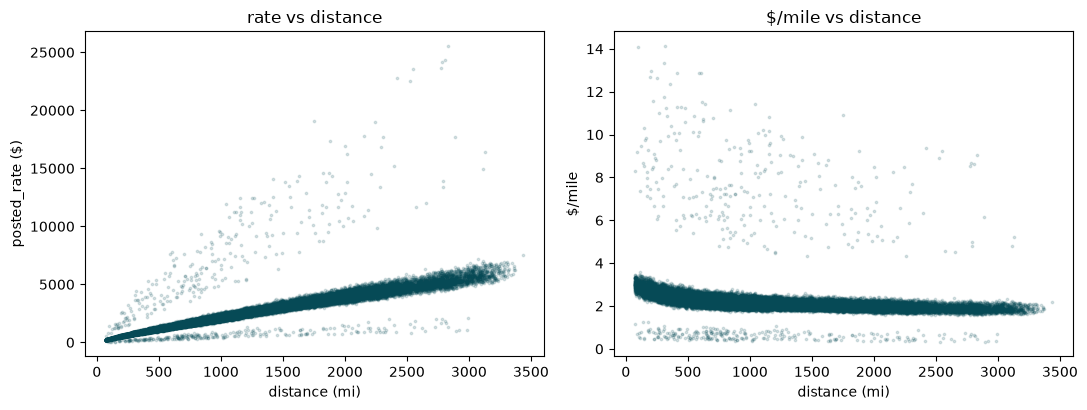

count    38477.000
mean         2.211
std          0.580
min          0.334
25%          1.983
50%          2.141
75%          2.339
max         14.125
Name: rate_per_mile, dtype: float64


In [5]:
print("corr(distance, posted_rate):", round(train["distance"].corr(train["posted_rate"]), 4))
print("corr(distance, log1p(posted_rate)):", round(train["distance"].corr(np.log1p(train["posted_rate"])), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(train["distance"], train["posted_rate"], s=3, alpha=0.15, color="#064A56")
axes[0].set_xlabel("distance (mi)"); axes[0].set_ylabel("posted_rate ($)")
axes[0].set_title("rate vs distance")

train["rate_per_mile"] = train["posted_rate"] / train["distance"]
axes[1].scatter(train["distance"], train["rate_per_mile"], s=3, alpha=0.15, color="#064A56")
axes[1].set_xlabel("distance (mi)"); axes[1].set_ylabel("$/mile")
axes[1].set_title("$/mile vs distance")
fig.tight_layout()
plt.show()

print(train["rate_per_mile"].describe().round(3))

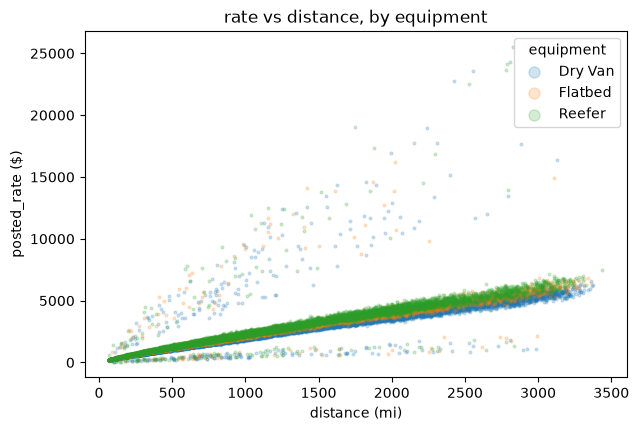

,count,mean,std,min,25%,50%,75%,max
equipment,,,,,,,,
Dry Van,21842.0,2.109,0.516,0.334,1.917,2.045,2.207,12.655
Flatbed,6983.0,2.294,0.644,0.354,2.070,2.213,2.399,12.950
Reefer,9652.0,2.380,0.619,0.386,2.164,2.310,2.493,14.125


In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for eq, sub in train.groupby("equipment"):
    ax.scatter(sub["distance"], sub["posted_rate"], s=4, alpha=0.2, label=eq)
ax.set_xlabel("distance (mi)"); ax.set_ylabel("posted_rate ($)")
ax.legend(markerscale=4, title="equipment")
ax.set_title("rate vs distance, by equipment")
plt.show()

train.groupby("equipment")["rate_per_mile"].describe().round(3)

## 4. Weight and equipment

weight describe:
 count    38242.0
mean     30991.7
std       9384.8
min     -47500.0
25%      25769.5
50%      31405.0
75%      36968.0
max      47500.0
Name: weight, dtype: float64

corr(weight, posted_rate): 0.0362
corr(weight, distance): 0.0043

equipment counts:
 equipment
Dry Van    21842
Reefer      9652
Flatbed     6983
Name: count, dtype: int64

rate by equipment:


,mean,median,std,count
equipment,,,,
Dry Van,2269.2,1953.4,1410.6,21842
Flatbed,2446.4,2082.3,1502.2,6983
Reefer,2540.5,2186.2,1580.9,9652


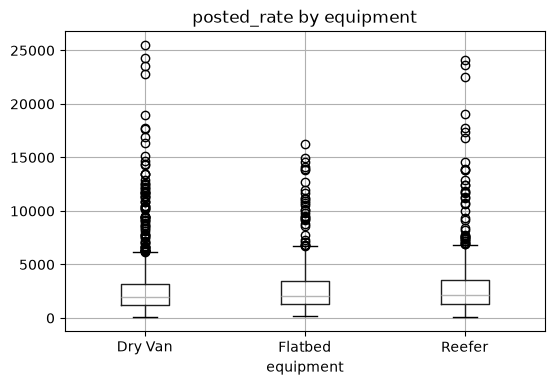

In [7]:
print("weight describe:\n", train["weight"].describe().round(1))
print("\ncorr(weight, posted_rate):", round(train["weight"].corr(train["posted_rate"]), 4))
print("corr(weight, distance):", round(train["weight"].corr(train["distance"]), 4))

print("\nequipment counts:\n", train["equipment"].value_counts())
print("\nrate by equipment:")
display(train.groupby("equipment")["posted_rate"].agg(["mean", "median", "std", "count"]).round(1))

fig, ax = plt.subplots(figsize=(6, 4))
train.boxplot(column="posted_rate", by="equipment", ax=ax)
ax.set_title("posted_rate by equipment"); plt.suptitle("")
plt.show()

## 5. Geography: cities, lanes, and coordinate sanity

Also checks how many `validation.csv` lanes are unseen in `train`, since that drives the
feature-engineering choice (lane target-encoding needs a fallback to city- or region-level
features for those novel lanes).

In [8]:
print("unique pickup cities:", train["pickup"].nunique())
print("unique delivery cities:", train["delivery"].nunique())
print("unique lanes (pickup, delivery):", train.groupby(["pickup", "delivery"]).ngroups)

# each city should have one fixed (lat, lon); check for inconsistency or typos
pickup_coords = train.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique()
inconsistent = pickup_coords[(pickup_coords["pickup_lat"] > 1) | (pickup_coords["pickup_lon"] > 1)]
print(f"\npickup cities with inconsistent coordinates: {len(inconsistent)}")
display(inconsistent)

# coordinate bounding box sanity (continental US roughly lat 24-50, lon -125 to -66)
lat_ok = train["pickup_lat"].between(20, 55) & train["delivery_lat"].between(20, 55)
lon_ok = train["pickup_lon"].between(-130, -60) & train["delivery_lon"].between(-130, -60)
print(f"\nrows with out-of-US-bbox coordinates: {(~(lat_ok & lon_ok)).sum()}")

unique pickup cities: 64
unique delivery cities: 64
unique lanes (pickup, delivery): 3999

pickup cities with inconsistent coordinates: 0


,pickup_lat,pickup_lon
pickup,,



rows with out-of-US-bbox coordinates: 0


In [9]:
validation = pd.read_csv("../data/validation.csv")

train_lanes = set(zip(train["pickup"], train["delivery"]))
full_train_lanes = set(zip(raw["pickup"], raw["delivery"]))  # all of Jan-Oct, not just EDA train
val_lanes = set(zip(validation["pickup"], validation["delivery"]))

novel_vs_eda_train = val_lanes - train_lanes
novel_vs_full_train = val_lanes - full_train_lanes

print(f"validation lanes: {len(val_lanes)}")
print(f"  unseen vs EDA-train (Jan-Aug):  {len(novel_vs_eda_train)} ({len(novel_vs_eda_train)/len(val_lanes):.1%})")
print(f"  unseen vs full train (Jan-Oct): {len(novel_vs_full_train)} ({len(novel_vs_full_train)/len(val_lanes):.1%})")

# are novel lanes still built from known cities, or are the cities themselves new?
known_cities = set(raw["pickup"]) | set(raw["delivery"])
val_cities = set(validation["pickup"]) | set(validation["delivery"])
print(f"\nvalidation cities unseen in train: {val_cities - known_cities}")

validation lanes: 4214
  unseen vs EDA-train (Jan-Aug):  743 (17.6%)
  unseen vs full train (Jan-Oct): 736 (17.5%)

validation cities unseen in train: {'Charlotte', 'Chicago', 'Jackson', 'Norfolk', 'Allentown', 'San Diego', 'Knoxville', 'Laredo'}


In [10]:
# rate/mile by pickup city: do hub cities behave differently? (top/bottom 10 by volume)
by_pickup = train.groupby("pickup").agg(
    n=("posted_rate", "size"),
    avg_rate=("posted_rate", "mean"),
    avg_rpm=("rate_per_mile", "mean"),
).sort_values("n", ascending=False)
print("Top 10 pickup cities by volume:")
display(by_pickup.head(10).round(2))
print("\nBottom 10 pickup cities by volume:")
display(by_pickup.tail(10).round(2))

Top 10 pickup cities by volume:


,n,avg_rate,avg_rpm
pickup,,,
Oklahoma City,980,2241.15,2.26
Lexington,968,1799.21,2.32
Bakersfield,948,3509.47,2.07
Richmond,941,2315.21,2.18
Fort Wayne,935,2001.08,2.17
Phoenix,910,3721.65,2.07
Hartford,909,2667.14,2.14
Baton Rouge,906,2095.68,2.29
Nashville,899,1795.03,2.34



Bottom 10 pickup cities by volume:


,n,avg_rate,avg_rpm
pickup,,,
Austin,327,2432.80,2.25
New Orleans,325,1985.66,2.35
Salt Lake City,322,3126.96,2.06
Birmingham,299,1853.93,2.29
Washington,277,2290.02,2.24
Louisville,268,1813.27,2.34
Detroit,263,2136.96,2.16
St. Louis,246,1905.56,2.30
Dallas,227,2170.02,2.44


## 6. Date / seasonality

Validation is Nov–Dec, entirely outside the train date range, so the model must extrapolate
the seasonal trend. Look at monthly, day-of-week, and day-of-year patterns to decide which
date features are worth engineering (and whether a linear trend or a cyclical one fits better).

           mean  median  count
date                          
2025-01  2256.0  1915.2   4918
2025-02  2273.8  1994.2   4337
2025-03  2372.3  2022.9   5036
2025-04  2372.2  2044.2   4819
2025-05  2421.8  2065.5   4913
2025-06  2497.0  2120.2   4783
2025-07  2415.2  2059.1   4912
2025-08  2338.4  2015.7   4759
2025-09  2406.4  2057.1   4670
2025-10  2379.1  2035.9   4853


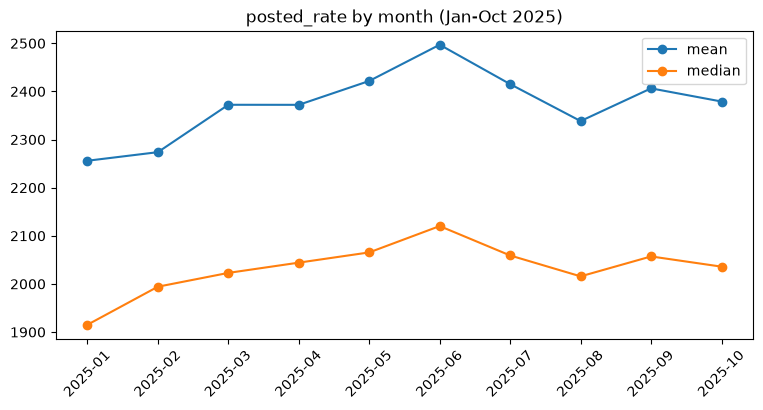

In [11]:
# use raw (full Jan-Oct) here to see the full trend, not just the EDA train slice
raw_d = raw.copy()
raw_d["date"] = pd.to_datetime(raw_d["date"])

monthly = raw_d.groupby(raw_d["date"].dt.to_period("M"))["posted_rate"].agg(["mean", "median", "count"])
print(monthly.round(1))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index.astype(str), monthly["mean"], marker="o", label="mean")
ax.plot(monthly.index.astype(str), monthly["median"], marker="o", label="median")
ax.set_title("posted_rate by month (Jan-Oct 2025)")
ax.legend(); ax.tick_params(axis="x", rotation=45)
plt.show()

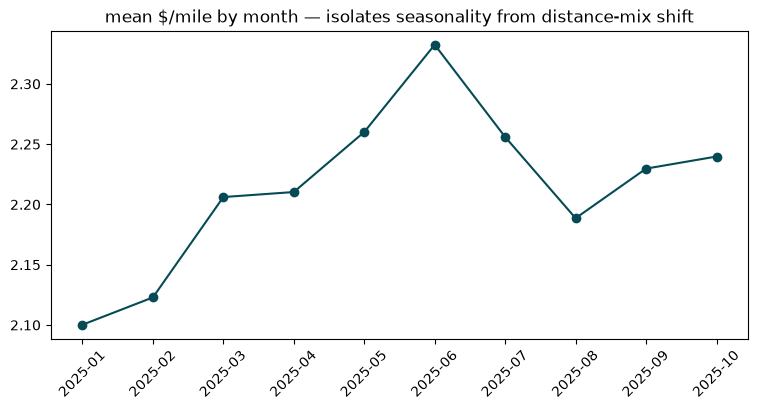


mean $/mile by day of week:
date
Monday       2.1964
Tuesday      2.2134
Wednesday    2.2484
Thursday     2.2446
Friday       2.2149
Saturday     2.1957
Sunday       2.1923
Name: rate_per_mile, dtype: float64


In [12]:
# monthly mean $/mile controls for any month-to-month shift in the mix of lane distances
raw_d["rate_per_mile"] = raw_d["posted_rate"] / raw_d["distance"]
monthly_rpm = raw_d.groupby(raw_d["date"].dt.to_period("M"))["rate_per_mile"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_rpm.index.astype(str), monthly_rpm.values, marker="o", color="#064A56")
ax.set_title("mean $/mile by month (isolates seasonality from distance-mix shift)")
ax.tick_params(axis="x", rotation=45)
plt.show()

# day-of-week effect
dow = raw_d.groupby(raw_d["date"].dt.day_name())["rate_per_mile"].mean()
dow = dow.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
print("\nmean $/mile by day of week:")
print(dow.round(4))

## 7. Market features: `market_index`, `quote_signal`

Important caveat: these columns exist in `train`/`validation` but are **absent** from
`data/december-chart-inputs.csv`, so the final December predictions can't rely on them at
inference time. Only date and the fixed shipment features will be available there.

december-chart-inputs.csv columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
train columns not in december inputs: {'quote_signal', 'rate_per_mile', 'posted_rate', 'load_id', 'market_index', 'pickup_lon', 'pickup_lat', 'delivery_lat', 'delivery_lon'}

market_index / quote_signal summary:


,market_index,quote_signal
count,38176.000,38477.000
mean,1.122,2.061
std,0.161,0.288
min,0.732,0.692
25%,0.992,1.889
50%,1.120,2.054
75%,1.253,2.219
max,1.468,3.610



correlation with posted_rate:
market_index: 0.0462
quote_signal: -0.0536

market_index corr with day-of-year: 0.3563
quote_signal corr with distance: -0.0742


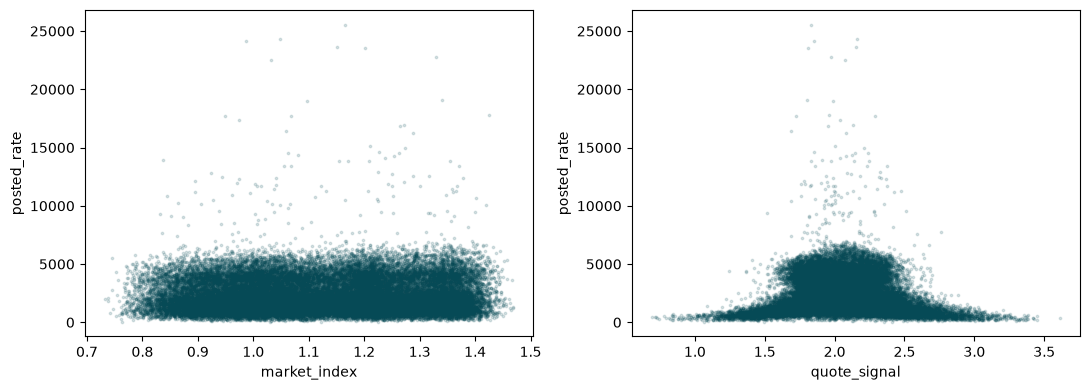

In [13]:
december_inputs = pd.read_csv("../data/december-chart-inputs.csv")
print("december-chart-inputs.csv columns:", list(december_inputs.columns))
print("train columns not in december inputs:", set(train.columns) - set(december_inputs.columns))

print("\nmarket_index / quote_signal summary:")
display(train[["market_index", "quote_signal"]].describe().round(3))

print("\ncorrelation with posted_rate:")
print("market_index:", round(train["market_index"].corr(train["posted_rate"]), 4))
print("quote_signal:", round(train["quote_signal"].corr(train["posted_rate"]), 4))

# do they correlate with date (i.e., encode seasonality) or with distance (encode lane)?
print("\nmarket_index corr with day-of-year:", round(train["market_index"].corr(train["date"].dt.dayofyear), 4))
print("quote_signal corr with distance:", round(train["quote_signal"].corr(train["distance"]), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(train["market_index"], train["posted_rate"], s=3, alpha=0.15, color="#064A56")
axes[0].set_xlabel("market_index"); axes[0].set_ylabel("posted_rate")
axes[1].scatter(train["quote_signal"], train["posted_rate"], s=3, alpha=0.15, color="#064A56")
axes[1].set_xlabel("quote_signal"); axes[1].set_ylabel("posted_rate")
fig.tight_layout()
plt.show()

## 8. Duplicate / ID sanity checks

In [14]:
print("duplicate load_id in raw:", raw["load_id"].duplicated().sum())
print("fully duplicate rows (excluding load_id):", raw.drop(columns="load_id").duplicated().sum())
print("self-lane rows (pickup == delivery):", (raw["pickup"] == raw["delivery"]).sum())
print("zero/negative distance rows:", (raw["distance"] <= 0).sum())
print("zero/negative weight rows:", (raw["weight"] <= 0).sum())
print("non-positive posted_rate rows:", (raw["posted_rate"] <= 0).sum())

duplicate load_id in raw: 0
fully duplicate rows (excluding load_id): 0
self-lane rows (pickup == delivery): 0
zero/negative distance rows: 0
zero/negative weight rows: 292
non-positive posted_rate rows: 0


## 9. Daily market index: a diagnostic ritual for the daily series

This is panel data (~115–200 loads/day), not one series, so the classic time-series
diagnostics apply to the **aggregated daily index**: the daily median $/mile. Train slice
(Jan–Aug) only. Ritual: plot the daily series → STL decomposition → ACF/PACF → ADF + KPSS →
read off transform, seasonal period, and lag features. This decides how the Nov–Dec
extrapolation should be handled (trend term? two-stage daily-index model? date features only?).

days: 243 | missing days: 0
loads/day: {'count': 243.0, 'mean': 158.3, 'std': 12.7, 'min': 115.0, '25%': 151.0, '50%': 158.0, '75%': 166.0, 'max': 198.0}


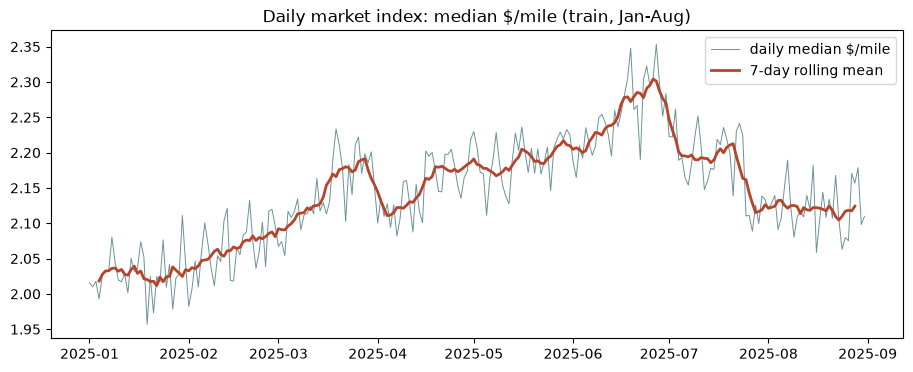

In [15]:
daily = (
    train.groupby("date")
    .agg(rpm_median=("rate_per_mile", "median"), rpm_mean=("rate_per_mile", "mean"), n=("rate_per_mile", "size"))
    .asfreq("D")
)
print("days:", len(daily), "| missing days:", int(daily["rpm_median"].isna().sum()))
print("loads/day:", daily["n"].describe().round(1).to_dict())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily.index, daily["rpm_median"], lw=0.7, alpha=0.6, color="#064A56", label="daily median $/mile")
ax.plot(daily.index, daily["rpm_median"].rolling(7, center=True).mean(), lw=2, color="#B5442A", label="7-day rolling mean")
ax.set_title("Daily market index: median $/mile (train, Jan-Aug)")
ax.legend()
plt.show()

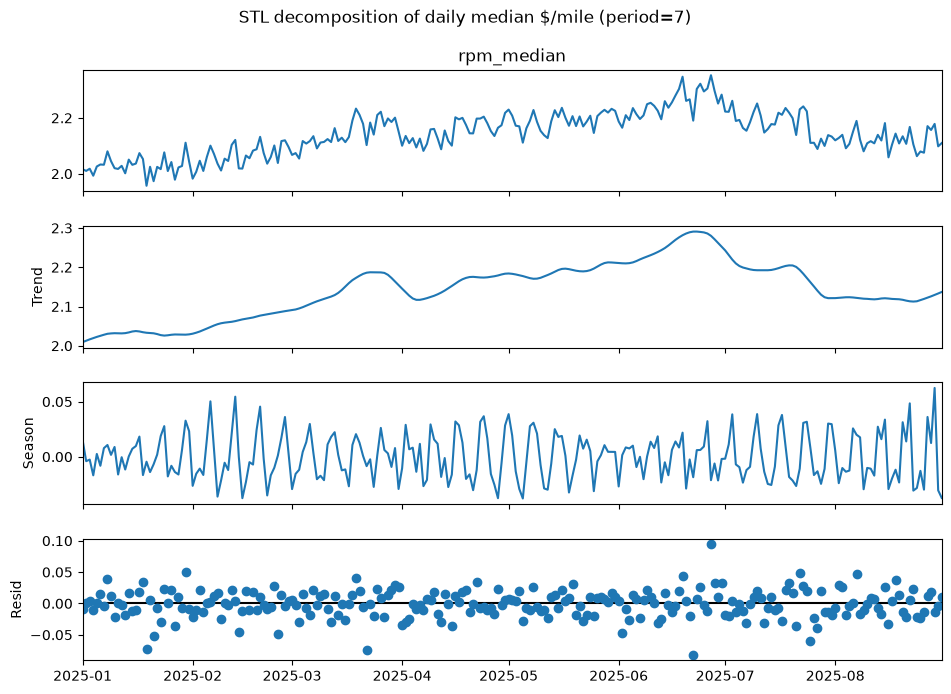

trend strength: 0.913 | weekly seasonal strength: 0.504


In [16]:
from statsmodels.tsa.seasonal import STL

stl = STL(daily["rpm_median"], period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(10, 7)
fig.suptitle("STL decomposition of daily median $/mile (period=7)", y=1.01)
plt.show()

# strength of trend / seasonality (FPP3 definitions)
f_trend = max(0.0, 1 - np.var(stl.resid) / np.var(stl.trend + stl.resid))
f_seas = max(0.0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
print(f"trend strength: {f_trend:.3f} | weekly seasonal strength: {f_seas:.3f}")

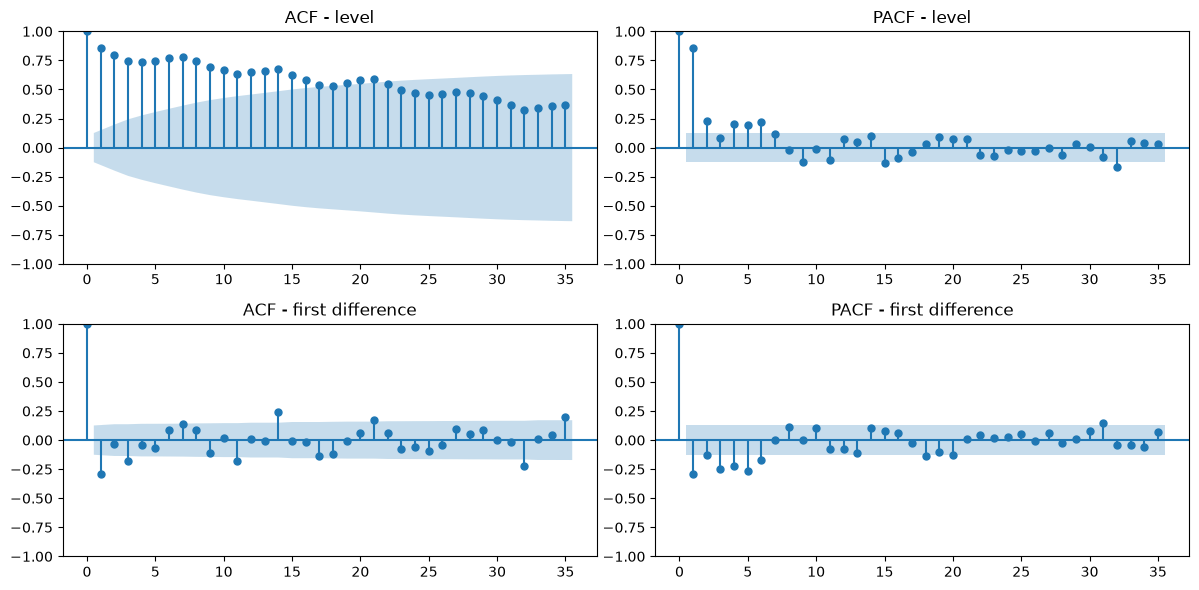

level             ADF p=0.4394 (non-stationary) | KPSS p=0.0100 (non-stationary) -> unit root -> difference
first difference  ADF p=0.0000 (stationary    ) | KPSS p=0.0417 (non-stationary) -> heteroskedasticity / structural break -> inspect


In [17]:
import warnings

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

level = daily["rpm_median"].dropna()
diff = level.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
plot_acf(level, lags=35, ax=axes[0, 0], title="ACF - level")
plot_pacf(level, lags=35, ax=axes[0, 1], method="ywm", title="PACF - level")
plot_acf(diff, lags=35, ax=axes[1, 0], title="ACF - first difference")
plot_pacf(diff, lags=35, ax=axes[1, 1], method="ywm", title="PACF - first difference")
fig.tight_layout()
plt.show()


def stationarity_verdict(series, name):
    adf_p = adfuller(series, autolag="AIC")[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # kpss warns when p falls outside its lookup table
        kpss_p = kpss(series, regression="c", nlags="auto")[1]
    adf_say = "stationary" if adf_p < 0.05 else "non-stationary"
    kpss_say = "non-stationary" if kpss_p < 0.05 else "stationary"
    combo = {
        ("stationary", "stationary"): "stationary -> model directly",
        ("non-stationary", "non-stationary"): "unit root -> difference",
        ("non-stationary", "stationary"): "trend-stationary -> detrend, don't difference",
        ("stationary", "non-stationary"): "heteroskedasticity / structural break -> inspect",
    }[(adf_say, kpss_say)]
    print(f"{name:17s} ADF p={adf_p:.4f} ({adf_say:14s}) | KPSS p={kpss_p:.4f} ({kpss_say:14s}) -> {combo}")


stationarity_verdict(level, "level")
stationarity_verdict(diff, "first difference")

## 10. Conditional outliers: rate relative to what the load *should* cost

Section 2's global top/bottom-10 check misses loads mispriced *for their distance* (an outlier
is anomalous relative to its context, not the global distribution). Fit a deliberately simple
pricing model (log-rate ~ log-distance + equipment) and flag robust-z outliers in its
residuals.

In [18]:
from sklearn.linear_model import LinearRegression

X = pd.concat(
    [np.log1p(train[["distance"]]), pd.get_dummies(train["equipment"], drop_first=True)], axis=1
).astype(float)
y = np.log1p(train["posted_rate"])
pricing_model = LinearRegression().fit(X, y)
resid = y - pricing_model.predict(X)
print(f"simple pricing model R^2 (log scale): {pricing_model.score(X, y):.4f}")

mad = (resid - resid.median()).abs().median()
robust_z = (resid - resid.median()) / (1.4826 * mad)
flag_hi, flag_lo = robust_z > 4, robust_z < -4
print(f"\nconditional outliers (|robust z| > 4): {flag_hi.sum()} overpriced, {flag_lo.sum()} underpriced")
print(f"for reference: $/mile > 5: {(train['rate_per_mile'] > 5).sum()} rows | $/mile < 0.75: {(train['rate_per_mile'] < 0.75).sum()} rows")

cols = ["pickup", "delivery", "distance", "equipment", "posted_rate", "rate_per_mile"]
print("\nMost underpriced for their distance:")
display(train.loc[robust_z.nsmallest(5).index, cols].assign(robust_z=robust_z.nsmallest(5).round(2)))
print("Most overpriced for their distance:")
display(train.loc[robust_z.nlargest(5).index, cols].assign(robust_z=robust_z.nlargest(5).round(2)))

simple pricing model R^2 (log scale): 0.9423

conditional outliers (|robust z| > 4): 268 overpriced, 266 underpriced
for reference: $/mile > 5: 250 rows | $/mile < 0.75: 196 rows

Most underpriced for their distance:


,pickup,delivery,distance,equipment,posted_rate,rate_per_mile,robust_z
4674,Hartford,Baltimore,149.3,Reefer,75.19,0.503617,-31.88
508,Las Vegas,Grand Rapids,1976.4,Flatbed,699.41,0.353881,-31.72
2511,Buffalo,San Antonio,1644.3,Flatbed,596.04,0.362489,-31.71
17602,Fort Wayne,Philadelphia,807.7,Flatbed,328.89,0.407193,-31.23
33585,Fresno,Los Angeles,416.2,Dry Van,171.28,0.411533,-31.09


Most overpriced for their distance:


,pickup,delivery,distance,equipment,posted_rate,rate_per_mile,robust_z
22254,Greensboro,Cincinnati,314.7,Reefer,4445.23,14.125294,30.23
28012,Montgomery,Houston,604.3,Reefer,7773.37,12.863429,30.07
27969,Buffalo,Boston,589.9,Reefer,7597.52,12.879335,30.04
23369,Amarillo,Lubbock,412.4,Flatbed,5308.96,12.873327,29.88
21968,Jacksonville,Columbia,254.5,Dry Van,3220.66,12.654853,29.88


## 11. Distance vs haversine: circuity sanity check

`distance` should be road miles ≈ 1.15–1.3× the great-circle (haversine) distance between the
coordinates. Large deviations flag data issues; the circuity ratio itself is a candidate
feature. (The coordinates are synthetic/jittered, e.g. Philadelphia's longitude sits in the
Atlantic, so `distance` is not derivable from them; this check is about internal consistency.)

In [19]:
def haversine_miles(lat1, lon1, lat2, lon2):
    r = 3958.8
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    return 2 * r * np.arcsin(
        np.sqrt(np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2)
    )


train["haversine"] = haversine_miles(train["pickup_lat"], train["pickup_lon"], train["delivery_lat"], train["delivery_lon"])
train["circuity"] = train["distance"] / train["haversine"]
print("circuity ratio (distance / haversine):")
print(train["circuity"].describe().round(3))

high = train[train["circuity"] > 1.5]
print(f"\nrows with circuity > 1.5: {len(high)} | their median haversine: {high['haversine'].median():.0f} mi (short hauls)")
print(f"rows with distance exactly 70.0: {(train['distance'] == 70.0).sum()} -> looks like a distance floor")
print("\nlanes among circuity > 1.5 rows:")
print(high.groupby(["pickup", "delivery"]).size().sort_values(ascending=False).head(8))

circuity ratio (distance / haversine):
count    38477.000
mean         1.195
std          0.152
min          1.058
25%          1.165
50%          1.182
75%          1.205
max          9.635
Name: circuity, dtype: float64

rows with circuity > 1.5: 179 | their median haversine: 56 mi (short hauls)
rows with distance exactly 70.0: 35 -> looks like a distance floor

lanes among circuity > 1.5 rows:
pickup        delivery    
Hartford      Philadelphia    14
Los Angeles   Phoenix         14
Philadelphia  Hartford        12
Phoenix       Los Angeles     10
Chattanooga   Atlanta         10
Washington    Richmond         9
Nashville     Chattanooga      8
Fort Wayne    Toledo           7
dtype: int64


## 12. Lane directionality (headhaul / backhaul)

In real freight, A→B and B→A price differently (trucks must reposition). If that asymmetry
exists here, direction-aware features help, especially for the 17.6% novel validation lanes,
where regional direction effects transfer even when the exact lane itself was never seen.

In [20]:
lane_stats = train.groupby(["pickup", "delivery"])["rate_per_mile"].agg(["mean", "size"])
fwd = lane_stats[lane_stats["size"] >= 5]
rev = fwd.rename_axis(["delivery", "pickup"]).swaplevel().rename(columns={"mean": "rev_mean", "size": "rev_size"})
pairs = fwd.join(rev, how="inner")
print(f"lane pairs with >=5 loads in both directions: {len(pairs)}")
print(f"corr(fwd $/mile, rev $/mile): {pairs['mean'].corr(pairs['rev_mean']):.3f}")
pairs["gap"] = pairs["mean"] - pairs["rev_mean"]
print(f"mean |fwd - rev| gap: ${pairs['gap'].abs().mean():.3f}/mile")

print("\nmost asymmetric lane pairs:")
display(pairs.reindex(pairs["gap"].abs().sort_values(ascending=False).index)[["mean", "rev_mean", "gap"]].head(8).round(3))

east = train["delivery_lon"] > train["pickup_lon"]
print(f"eastbound mean $/mile: {train.loc[east, 'rate_per_mile'].mean():.3f} | westbound: {train.loc[~east, 'rate_per_mile'].mean():.3f}")

lane pairs with >=5 loads in both directions: 2836
corr(fwd $/mile, rev $/mile): 0.629
mean |fwd - rev| gap: $0.137/mile

most asymmetric lane pairs:


,,mean,rev_mean,gap
pickup,delivery,,,
Little Rock,Tampa,2.325,4.047,-1.722
Tampa,Little Rock,4.047,2.325,1.722
Harrisburg,Mobile,2.108,3.781,-1.673
Mobile,Harrisburg,3.781,2.108,1.673
Albuquerque,Tucson,2.313,3.882,-1.569
Tucson,Albuquerque,3.882,2.313,1.569
Nashville,Tampa,3.808,2.255,1.553
Tampa,Nashville,2.255,3.808,-1.553


eastbound mean $/mile: 2.210 | westbound: 2.211


## 13. Seasonality × segment

Does the mid-year bump differ by equipment (reefer produce season is a real-world effect) or
by region? Decides whether month×equipment / month×region interactions are worth engineering,
and where the Nov–Dec extrapolation risk concentrates.

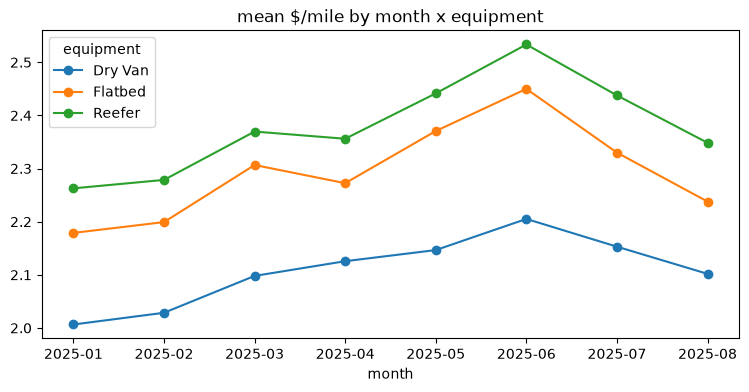

indexed to January (does the seasonal *shape* differ by equipment?):
equipment  Dry Van  Flatbed  Reefer
month                              
2025-01      1.000    1.000   1.000
2025-02      1.011    1.009   1.007
2025-03      1.046    1.059   1.047
2025-04      1.059    1.043   1.041
2025-05      1.070    1.088   1.079
2025-06      1.099    1.124   1.120
2025-07      1.073    1.069   1.077
2025-08      1.048    1.027   1.038


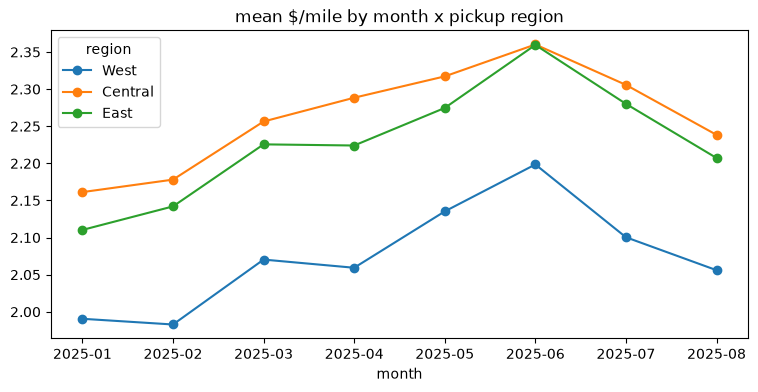

In [21]:
month = train["date"].dt.to_period("M").astype(str)

by_eq = train.assign(month=month).pivot_table(values="rate_per_mile", index="month", columns="equipment", aggfunc="mean")
by_eq.plot(marker="o", figsize=(9, 4), title="mean $/mile by month x equipment")
plt.show()
print("indexed to January (does the seasonal *shape* differ by equipment?):")
print((by_eq / by_eq.iloc[0]).round(3))

region = pd.cut(train["pickup_lon"], bins=[-130, -105, -90, -60], labels=["West", "Central", "East"])
by_region = train.assign(month=month, region=region).pivot_table(
    values="rate_per_mile", index="month", columns="region", aggfunc="mean", observed=True
)
by_region.plot(marker="o", figsize=(9, 4), title="mean $/mile by month x pickup region")
plt.show()

## 14. Covariate shift: train vs Sep-Oct vs validation (features only)

The dev regime should resemble the test regime, so compare *feature* distributions only (no
Sep-Oct targets touched here) and check where the 8 novel validation cities sit geographically
relative to training coverage. Inside the coordinate range means a lat/lon-based model
interpolates; outside means it extrapolates.

distance quantiles:


,train (Jan-Aug),Sep-Oct,validation (Nov-Dec)
0.1,328.0,327.0,328.0
0.5,955.0,946.0,954.0
0.9,2210.0,2239.0,2225.0


weight median: {'train (Jan-Aug)': 31405, 'Sep-Oct': 31562, 'validation (Nov-Dec)': 31193}

equipment mix (%):


,train (Jan-Aug),Sep-Oct,validation (Nov-Dec)
equipment,,,
Dry Van,56.8,56.3,56.5
Reefer,25.1,25.1,25.4
Flatbed,18.1,18.6,18.1


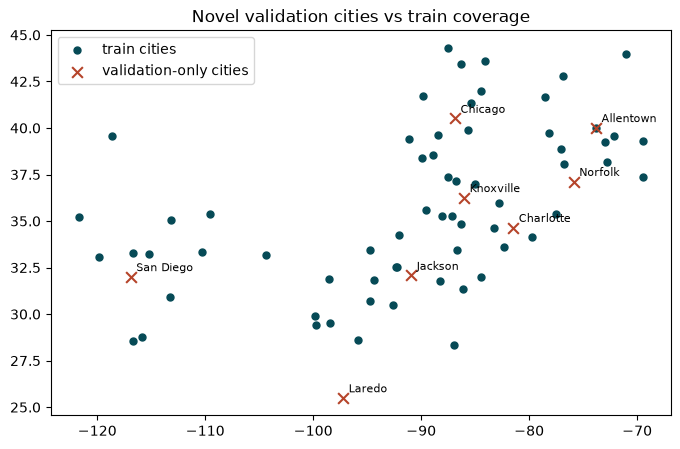

novel cities inside the train lat/lon bounding box: 7/8
outside: ['Laredo']


In [22]:
sep_oct = raw_d[raw_d["date"] >= "2025-09-01"]
frames = {"train (Jan-Aug)": train, "Sep-Oct": sep_oct, "validation (Nov-Dec)": validation}

print("distance quantiles:")
display(pd.DataFrame({k: v["distance"].quantile([0.1, 0.5, 0.9]) for k, v in frames.items()}).round(0))
print("weight median:", {k: round(v["weight"].median()) for k, v in frames.items()})
print("\nequipment mix (%):")
display(pd.DataFrame({k: v["equipment"].value_counts(normalize=True) * 100 for k, v in frames.items()}).round(1))


def city_coords(df):
    p = df.rename(columns={"pickup": "city", "pickup_lat": "lat", "pickup_lon": "lon"})[["city", "lat", "lon"]]
    d = df.rename(columns={"delivery": "city", "delivery_lat": "lat", "delivery_lon": "lon"})[["city", "lat", "lon"]]
    return pd.concat([p, d]).groupby("city")[["lat", "lon"]].first()


train_cities = city_coords(train)
novel = city_coords(validation).loc[lambda c: ~c.index.isin(train_cities.index)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train_cities["lon"], train_cities["lat"], s=25, color="#064A56", label="train cities")
ax.scatter(novel["lon"], novel["lat"], s=60, color="#B5442A", marker="x", label="validation-only cities")
for name, row in novel.iterrows():
    ax.annotate(name, (row["lon"], row["lat"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title("Novel validation cities vs train coverage")
ax.legend()
plt.show()

inside = novel["lat"].between(train_cities["lat"].min(), train_cities["lat"].max()) & novel["lon"].between(
    train_cities["lon"].min(), train_cities["lon"].max()
)
print(f"novel cities inside the train lat/lon bounding box: {inside.sum()}/{len(novel)}")
if not inside.all():
    print("outside:", list(novel.index[~inside]))

## 15. Market features, conditionally

Section 7 found near-zero *raw* correlation for `market_index`/`quote_signal`. That can hide
a real conditional effect (distance dominates the raw target). Check their correlation with
the §10 pricing-model residuals, and whether the *daily mean* of `market_index` tracks the
daily rate index: if it does, it is forecastable into December even though absent from the
chart inputs.

corr with pricing-model residual (log scale):
  market_index: 0.1855
  quote_signal: 0.0301
median per-day distinct market_index values: 156.0 -> load-level, not a daily series

corr(daily mean market_index, daily median $/mile): 0.8201


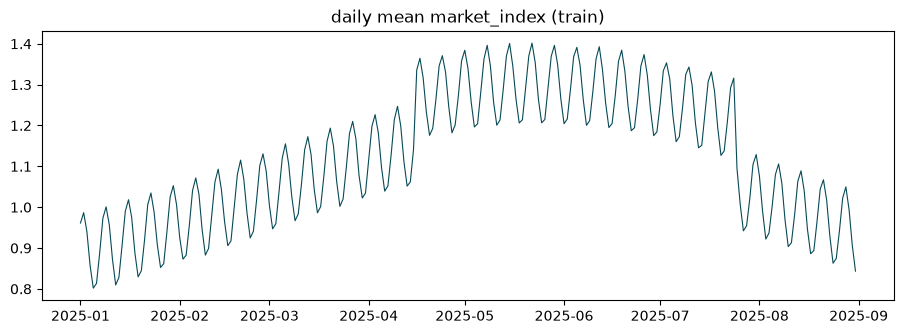

In [23]:
print("corr with pricing-model residual (log scale):")
print("  market_index:", round(train["market_index"].corr(resid), 4))
print("  quote_signal:", round(train["quote_signal"].corr(resid), 4))
print("median per-day distinct market_index values:", train.groupby("date")["market_index"].nunique().median(),
      "-> load-level, not a daily series")

daily_mi = train.groupby("date")["market_index"].mean()
print("\ncorr(daily mean market_index, daily median $/mile):", round(daily_mi.corr(daily["rpm_median"]), 4))

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(daily_mi.index, daily_mi, lw=0.8, color="#064A56")
ax.set_title("daily mean market_index (train)")
plt.show()

## 16. Baseline anchors (recorded for the Phase 4 table)

Never evaluate a model without a baseline floor. Fit on Jan–Jun, evaluate on Jul–Aug (a
2-month-ahead split entirely inside the EDA train slice, no dev/holdout touched). These
numbers are the floor every Phase 4 model must beat.

In [24]:
fit = train[train["date"] < "2025-07-01"]
evl = train[train["date"] >= "2025-07-01"]


def report(name, pred):
    err = evl["posted_rate"] - pred
    print(f"{name:36s} MAE ${err.abs().mean():7.1f} | RMSE ${np.sqrt((err ** 2).mean()):7.1f}")


report("b0: global median $/mile x distance", fit["rate_per_mile"].median() * evl["distance"])

lane_rpm = fit.groupby(["pickup", "delivery"])["rate_per_mile"].median()
lane_pred = pd.Series(
    evl.set_index(["pickup", "delivery"]).index.map(lane_rpm), index=evl.index
).fillna(fit["rate_per_mile"].median()) * evl["distance"]
report("b1: lane median $/mile x distance", lane_pred)

Xf = pd.concat([np.log1p(fit[["distance"]]), pd.get_dummies(fit["equipment"], drop_first=True)], axis=1).astype(float)
Xe = pd.concat([np.log1p(evl[["distance"]]), pd.get_dummies(evl["equipment"], drop_first=True)], axis=1).astype(float)[Xf.columns]
lin = LinearRegression().fit(Xf, np.log1p(fit["posted_rate"]))
report("b2: linear log-rate ~ log-dist + eq", np.expm1(lin.predict(Xe)))

b0: global median $/mile x distance  MAE $  249.0 | RMSE $  674.7
b1: lane median $/mile x distance    MAE $  191.4 | RMSE $  657.4
b2: linear log-rate ~ log-dist + eq  MAE $  134.9 | RMSE $  631.8


## Summary of key findings

- **Target (`posted_rate`)**: right-skewed (skew 1.90, mean $2,369 vs median $2,026, max $25,533).
  `log1p` brings skew to -0.49, so we should train on log(rate) and predict with `expm1`. The
  99.5th percentile is ~$6,469 with 193 rows above it; spot-checked the top rows and they pair
  with long distances, so they look like genuine long-haul loads, not corrupted data. No
  clipping planned.

- **Distance**: by far the strongest single predictor, `corr(distance, posted_rate) = 0.910`
  (0.899 on log-rate). $/mile is fairly flat with distance (median ~$2.14/mi, IQR
  $1.98–$2.34), so there's no strong non-linear discount curve. Distance likely enters
  near-linearly plus whatever the tree model finds.

- **Weight / equipment**: weight barely correlates with rate (`corr = 0.036`) and is
  independent of distance (`corr = 0.004`), so it's a weak but real feature. Equipment ordering:
  Reefer > Flatbed > Dry Van in both mean and median rate, so keep as a categorical feature.
  Dry Van is the majority class (57% of rows).

- **Geography**: 64 pickup / 64 delivery cities, 3,999 lanes in train. Coordinates are
  internally consistent (each city maps to exactly one lat/lon, no bounding-box outliers).
  **17.6% of validation lanes (743 of 4,214) are unseen in train**, and 8 validation cities
  (Chicago, Norfolk, Knoxville, Allentown, Charlotte, San Diego, Jackson, Laredo) never
  appear in train at all, so pure lane- or city-label encoding will fail on these. Lat/lon-based
  and region-level features are required for the model to generalize to them.

- **Date / seasonality**: monthly mean rate drifts mildly upward from Jan ($2,256) to Jun
  ($2,497) before easing to Oct ($2,379): a soft mid-year bump, not a strong trend, so
  extrapolating into Nov–Dec needs some caution (there's no obvious linear trend to extend).
  Day-of-week effect is small (~2.4% spread, Wed/Thu highest, weekends lowest), worth including
  but not a major driver.

- **Market features (`market_index`, `quote_signal`)**: both are weakly correlated with rate
  directly (0.046 and -0.054) despite `market_index` tracking day-of-year (`corr = 0.356`), so
  it partially encodes seasonality already baked into training data. **Critically, neither
  column exists in `december-chart-inputs.csv`**, so the December chart predictions cannot
  depend on them; the final pipeline needs a defined fallback (e.g., train-median fill) for
  any inference path that lacks them.

- **Data quality issues found and how to address them (→ Phase 2)**:
  1. **Negative/zero weight**: 292 rows in train (0.6%), 145 in validation (1.2%). Values are
     exact negations of plausible weights (range 5,000–47,500 lb), which looks like a
     sign-flip entry bug, not garbage. Fix: `weight = weight.abs()`, not a drop.
  2. **Missing values**: `weight` (0.6% train / 1.4% val) and `market_index` (0.8% train /
     2.1% val) only. No missingness in any other column. GBDT models (LightGBM/XGBoost)
     handle NaN natively, so no imputation is required, but the `market_missing` flag is
     still worth adding as a feature.
  3. **No duplicate `load_id`s, no fully-duplicate rows, no self-lane (`pickup == delivery`)
     rows, no non-positive `distance` or `posted_rate`, no out-of-US-bounding-box
     coordinates**: the rest of the data is clean.

**Net effect on the plan**: proceed with log-target GBDT models, add lat/lon + city/region
features (not just lane target-encoding) to handle the 17.6% novel-lane rate in validation,
fix the weight sign-flip bug, and design the feature pipeline so the December-chart inference
path works without `market_index`/`quote_signal`.

---

### Aug 22 additions (sections 9-16): findings

- **Daily market index (§9)**: trend strength 0.913, weekly seasonal strength 0.504 (STL,
  period 7). ADF (p=0.44) and KPSS (p=0.01) both call the level non-stationary, so the market
  level **drifts like a random walk with weekly seasonality**; the first difference is
  stationary by ADF (KPSS marginal, p=0.04). Calendar features fitted on Jan–Aug cannot be
  trusted to extrapolate the Nov–Dec *level*; the final model needs an explicit trend/level
  strategy, and that risk must be documented.
- **Conditional outliers (§10)**: log-rate ~ log-distance + equipment alone explains
  **R² = 0.942**. Robust-z (>4) residual outliers: 268 overpriced + 266 underpriced (~1.4% of
  train), including long hauls under $0.75/mile that the global top/bottom check in §2 missed.
  Revisit the "no clipping" decision for these: keep the rows, but prefer Huber/quantile loss
  or winsorize the extreme residuals.
- **Circuity (§11)**: distance/haversine has median 1.18 (plausible road circuity), but 179
  rows exceed 1.5×, concentrated on short hauls, and `distance` has a floor at exactly
  70.0 mi (35 rows). Circuity ratio is a candidate feature; the floor is a data-quality caveat.
- **Directionality (§12)**: forward vs reverse lane $/mile correlate only 0.629, with a mean
  |gap| of $0.137/mile: real headhaul/backhaul asymmetry at lane level (but no aggregate
  east/west bias: 2.210 vs 2.211). Direction-aware regional features are justified.
- **Seasonality × segment (§13)**: the monthly shape indexed to January is nearly identical
  across equipment types (all peak ~+10–12% in June) and regions, so **no month×equipment
  interaction features are needed**.
- **Covariate shift (§14)**: distance/weight/equipment mixes are stable across train, Sep–Oct,
  and validation. 7 of 8 novel validation cities sit inside the train coordinate bounding box
  (interpolation is fine); **Laredo is outside** (south of all training data), so expect the
  worst novel-city errors there.
- **Market features (§15)**: `market_index` correlates 0.186 with the pricing residual (a
  real conditional signal) and its **daily mean tracks the daily median $/mile at r = 0.82**,
  meaning it is a noisy per-load observation of the daily market level. Since it is absent at
  inference, don't median-fill it: either drop it, or model the daily level explicitly
  (the two-stage design §9 already motivates).
- **Baseline anchors (§16)** (fit Jan–Jun, evaluate Jul–Aug): global median $/mile × distance
  MAE $249, lane-median $/mile × distance MAE $191, linear log-rate ~ log-distance +
  equipment MAE $135 / RMSE $632. These are the floors for the Phase 4 model table.